# RFI survey
`INPUTS`에 `raw_sweeps.csv` 경로 또는 관측 폴더를 지정하고 **Restart Kernel → Run All**합니다.
기본 입력은 2026-09-15의 300초 관측입니다. CSV의 주파수 열과 UTC timestamp를 그대로 읽으며 NPZ는 필요하지 않습니다.
`session.json`, `metadata_sweeps.json`도 같은 폴더에 있어야 합니다. 누락되면 `fetch-data.ps1 -Run`으로 run 전체를 받으세요.

자료 경로는 `data/날짜_site/Pi원본run명/raw_sweeps.csv`, 그림은 `RFI/figures/날짜_site/Pi원본run명/`입니다.
이전 다중 CSV 및 `run/raw/` 구조도 지원합니다. 다른 주파수 격자/설정/site는 합치지 않습니다.
기본 출력은 전체/50–350 MHz waterfall과 spectrum입니다. 큰 글꼴, UTC/KST 세로축, 왼쪽 정렬 제목을 유지합니다.

`max_dbm`은 각 시간 창에서 수집된 sweep의 주파수별 최댓값입니다.
`mean_peak_power_dbm`은 샘플링된 Positive Peak sweep의 선형 전력 평균이며 연속 RMS 적분이나 교정된 noise power가 아닙니다.
원시 파일은 수정하지 않으며 분석 NPZ 저장은 기본 OFF입니다.

In [24]:
%matplotlib inline
from pathlib import Path
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path(r'D:/Programing/LAMBDA/RFI')
SOURCE_DIR = PROJECT_DIR / 'source'
sys.path.insert(0, str(SOURCE_DIR))
from survey_analysis import resolve_run_inputs, load_runs, integrate_windows, integrated_plot, spectrum_plot, save_combined

In [52]:
DATA_ROOT = Path(r'D:/Research/01_ObsCAL_LAMBDA/04_Construction/05_RFI_Survey/data')
INPUTS = list(DATA_ROOT.rglob('**/2026091*'))[-1]
INPUTS

WindowsPath('D:/Research/01_ObsCAL_LAMBDA/04_Construction/05_RFI_Survey/data/2026-09-16_UNDEF/20260916T033754Z')

- 801점으로 생성된 trace에 991 points를 강제 설정하면, 톤 인덱스는 그대로인데 반환 길이만 바뀌는 동작
- 관측된 동작은 `:SWE:POIN` 설정값/응답 길이와 실제 trace의 주파수 좌표가 불일치하는 것이다.
기존 코드가 `linspace(start, stop, len(trace))`를 믿고 모든 반환값에 주파수를 붙인 것이 직접적인
저장 축 오류를 만들었다. 숫자 readback과 응답 길이만 일치한다고 축이 검증된 것은 아니었다.
- SA에 `:SWE:POIN`을 보내지 않는다. 매 native sweep을 801점으로 검증한다.
요청 npoints는 **최종 CSV 출력 점 수**로 사용하며, 801점보다 크면 여러 실제 sweep을 합친다.

In [53]:
# Environment override is used only by automated validation; normal use edits INPUTS above.
if os.environ.get('RFI_ANALYSIS_RUNS_JSON'):
    INPUTS = json.loads(os.environ['RFI_ANALYSIS_RUNS_JSON'])
SAVE_ANALYSIS_NPZ = False  # Optional derived arrays only; raw CSV is never modified
WINDOW_SECONDS = 10
STATISTIC = 'max_dbm'  # Or 'mean_peak_power_dbm'
TIME_ZONE = 'KST'  # Or 'UTC'
USER_TEXT = None  # None: settings-derived suffix; string: your own text
FOCUS_MHZ = (50, 350)  # None: no focused figure
VMIN, VMAX = None, None
ANALYSIS_NAME = None  # Required output subfolder name when combining multiple runs

RUN_DIRS = resolve_run_inputs(INPUTS, DATA_ROOT)
if not RUN_DIRS:
    raise ValueError('Choose at least one run')
if len(RUN_DIRS) > 1 and not ANALYSIS_NAME:
    raise ValueError('Set ANALYSIS_NAME for multi-run output; source settings must match')
if ANALYSIS_NAME and (Path(ANALYSIS_NAME).name != ANALYSIS_NAME or ANALYSIS_NAME in ('.', '..')):
    raise ValueError('ANALYSIS_NAME must be a single folder name')
if ANALYSIS_NAME:
    FIGURE_DIR = PROJECT_DIR / 'figures' / ANALYSIS_NAME
    PROCESSED_DIR = DATA_ROOT / '_analysis' / ANALYSIS_NAME
else:
    base = RUN_DIRS[0].parent if RUN_DIRS[0].name == 'raw' else RUN_DIRS[0]
    FIGURE_DIR = PROJECT_DIR / 'figures' / base.parent.name / base.name
    PROCESSED_DIR = base / 'processed'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
if SAVE_ANALYSIS_NPZ:
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## Load and quality checks
시간 창은 첫 기록 시작 시각부터 정렬하고 요청 timestamp로 sweep을 배정합니다. 중도 종료는 마지막 read까지, 시간 만료는 nominal deadline까지 표시합니다. 빈 창은 NaN이며 빈 창 0개도 연속 관측의 보증은 아닙니다.

In [54]:
data = load_runs(RUN_DIRS)
sessions = [json.loads((p / 'session.json').read_text()) for p in RUN_DIRS]
if not all(s.get('complete') for s in sessions):
    raise ValueError('Use completed recordings; live or failed sessions need separate recovery checks')
START_NS = min(int(s['start_utc_ns']) for s in sessions)
if all(s.get('reason') == 'duration_elapsed' for s in sessions):
    STOP_NS = max(int(s['deadline_utc_ns']) for s in sessions)
else:
    STOP_NS = int(data['read_complete_utc_ns'][-1])
windows = integrate_windows(data, WINDOW_SECONDS, start_utc_ns=START_NS, stop_utc_ns=STOP_NS)
FREQUENCY_RANGE = tuple(data['frequency_hz'][[0, -1]] / 1e6)
lo, hi = FREQUENCY_RANGE
rbw_khz = float(data['settings']['rbw_hz']) / 1000
grid_spacing = np.diff(data['frequency_hz'])[0] / 1e6
n_points = data['power_dbm'].shape[1]
TITLE_TEXT = USER_TEXT if USER_TEXT is not None else f'{lo:g}-{hi:g}MHz_{n_points:d}pts_RBW{rbw_khz:g}kHz_{WINDOW_SECONDS:g}s'
print('Inputs:', *RUN_DIRS, sep='\n  ')
print('Duration (s):', (STOP_NS - START_NS) / 1e9, '| metric:', STATISTIC)
print('Site:', data['site'], '| sweeps x points:', data['power_dbm'].shape)
print('Frequency range (MHz):', FREQUENCY_RANGE, '| RBW (kHz):', rbw_khz)
print(f'Grid spacing (MHz): {grid_spacing:.3f} (n_points={n_points})')
print('Windows:', len(windows['sweep_count']), '| empty:', np.count_nonzero(windows['sweep_count'] == 0))
print('Sweeps/window min-max:', windows['sweep_count'].min(), windows['sweep_count'].max())
print('Figures:', FIGURE_DIR)
print('Calibration: not applied; uncalibrated SA-input positive-peak data')

Inputs:
  D:\Research\01_ObsCAL_LAMBDA\04_Construction\05_RFI_Survey\data\2026-09-16_UNDEF\20260916T033754Z
Duration (s): 60.0 | metric: max_dbm
Site: UNDEF | sweeps x points: (12, 1601)
Frequency range (MHz): (np.float64(10.0), np.float64(1000.0)) | RBW (kHz): 100.0
Grid spacing (MHz): 0.619 (n_points=1601)
Windows: 6 | empty: 0
Sweeps/window min-max: 2 2
Figures: D:\Programing\LAMBDA\RFI\figures\2026-09-16_UNDEF\20260916T033754Z
Calibration: not applied; uncalibrated SA-input positive-peak data


## Waterfall
`STATISTIC`으로 시간 창 평균 또는 Max Hold를 선택합니다. 시간은 아래로 증가하며 회색은 비어 있는 창입니다. 확대 그림은 같은 데이터의 표시 범위만 바꾸며 주파수 분해능을 높이지 않습니다.

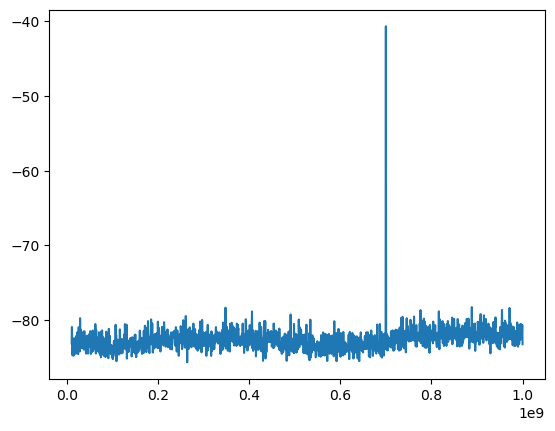

In [57]:
plt.plot(data['frequency_hz'], data['power_dbm'][-1])

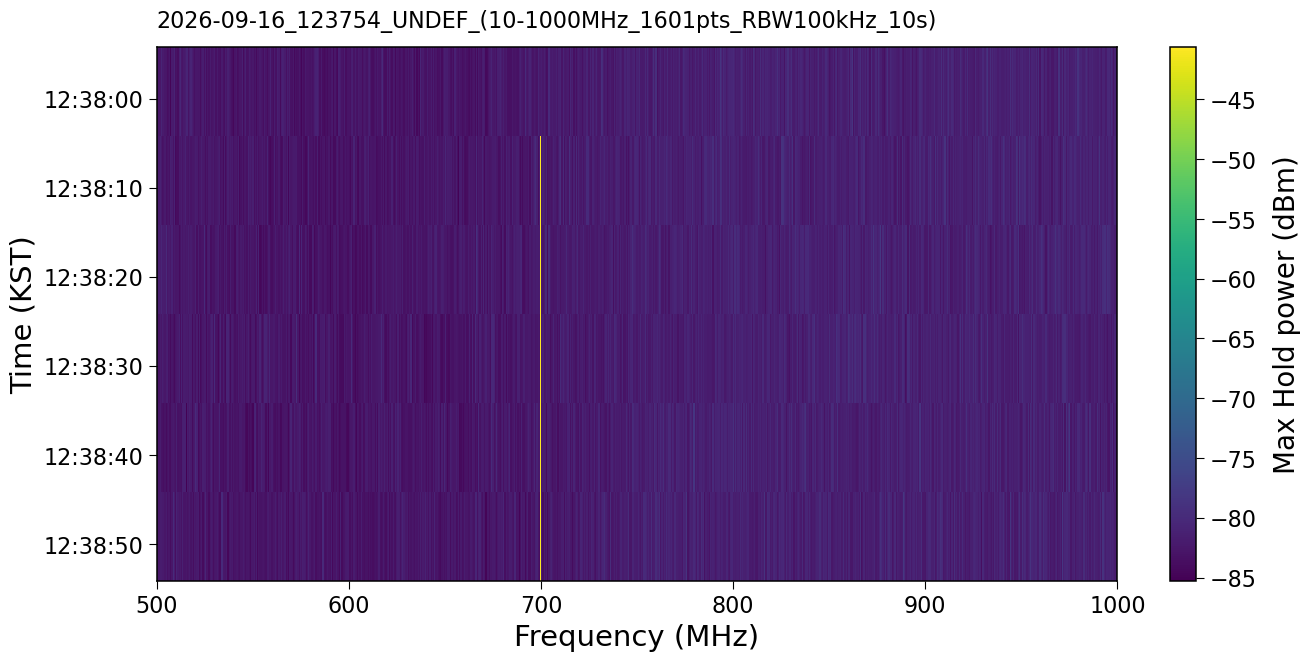

In [56]:
for bounds in [(500, 1000)]:
    fig, ax = integrated_plot(data, windows, metric=STATISTIC, frequency_range=bounds,
        time_axis=TIME_ZONE, title_text=TITLE_TEXT, vmin=VMIN, vmax=VMAX)
    fig.savefig(FIGURE_DIR / f'waterfall_{STATISTIC}_{WINDOW_SECONDS:g}s_{bounds[0]:g}-{bounds[1]:g}MHz_{TIME_ZONE}.png', dpi=200)
    plt.show()
    plt.close(fig)

## Spectrum and saved arrays
전체 spectrum은 원시 sweep을 동일 가중치로 평균하고 주파수별 최댓값도 표시합니다. 창 평균을 재평균하지 않습니다.
`SAVE_ANALYSIS_NPZ=True`일 때만 누적 Max Hold를 포함한 `combined_sweeps.npz`와 시간 창 분석 NPZ를 저장합니다. 원본부터 재생성하므로 반복 실행해도 중복 누적하지 않습니다.

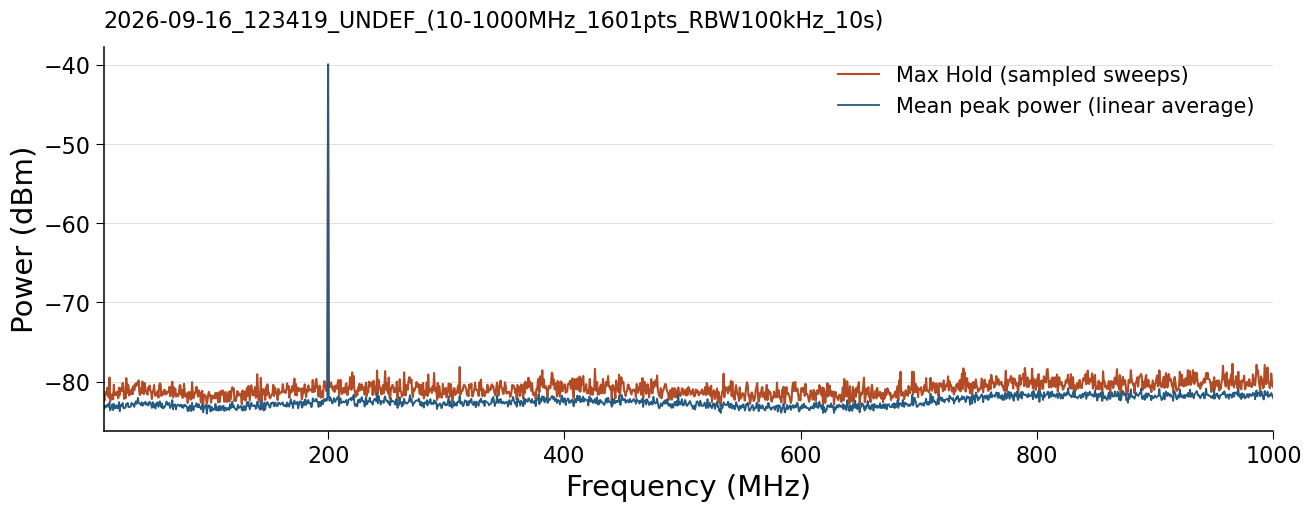

NPZ export disabled; analysis stays in memory and figures are saved.


In [51]:
fig, ax = spectrum_plot(data, frequency_range=FREQUENCY_RANGE, time_zone=TIME_ZONE, title_text=TITLE_TEXT)
fig.savefig(FIGURE_DIR / f'spectrum_{lo:g}-{hi:g}MHz_{TIME_ZONE}.png', dpi=200)
plt.show()
plt.close(fig)

if SAVE_ANALYSIS_NPZ:
    save_combined(data, PROCESSED_DIR / 'combined_sweeps.npz')
    metadata = {'source_directories': data['source_directories'], 'site': data['site'],
        'settings': data['settings'], 'window_seconds': WINDOW_SECONDS,
        'calibration_applied': False,
        'method': 'Equal-weight linear-power mean of sampled positive-peak sweeps; not continuous RMS integration'}
    np.savez_compressed(PROCESSED_DIR / f'windows_{WINDOW_SECONDS:g}s.npz',
        frequency_hz=data['frequency_hz'], metadata_json=np.array(json.dumps(metadata)), **windows)
    print('Saved analysis:', PROCESSED_DIR)
else:
    print("NPZ export disabled; analysis stays in memory and figures are saved.")